In [11]:
import torch
import glob
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

# This assumes 'utils.py' is in the same directory
from utils import SegmentFromFile

def evaluate_model(model_path, validation_data_directory, time_gap, device="cuda"):
    """
    Evaluates a fine-tuned Hugging Face classifier model on validation data.

    This function is adapted for models trained with the specific "T{num} G{num}"
    text format and does not use quantization or PEFT adapters.

    Args:
        model_path (str): Path to the directory containing the fine-tuned model.
        validation_data_directory (str): Path to the directory of validation CSV files.
        time_gap (float): The time gap used for segmenting the validation data.
        device (str): The device to run inference on (e.g., "cuda" or "cpu").

    Returns:
        dict: A dictionary containing performance metrics (accuracy, f1, precision, recall).
    """
    # --- 1. Load the Fine-Tuned Model and Tokenizer ---
    print(f"\n--- Starting Evaluation of Model: {model_path} ---")
    if not os.path.isdir(model_path):
        raise FileNotFoundError(f"Model directory not found at: {model_path}")

    print("Loading fine-tuned model and tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    # --- 2. Load and Process Validation Data ---
    print(f"Loading validation data from: {validation_data_directory}")
    all_chunks = []
    all_labels = []

    csv_files = glob.glob(os.path.join(validation_data_directory, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {validation_data_directory}")

    for file_path in tqdm(csv_files, desc="Processing validation files"):
        filename = os.path.basename(file_path)
        chunks, labels = SegmentFromFile(validation_data_directory, filename, time_gap=time_gap)
        all_chunks.extend(chunks)
        all_labels.extend(labels)

    print(f"Total validation segments loaded: {len(all_chunks)}")

    # --- 3. Format Data to Match Training Input ---
    # This MUST match the format used in the training script.
    def format_chunk_to_string(chunk):
        tokens = []
        for pair in chunk:
            token1 = f"T{int(pair[0])}"
            token2 = f"G{int(pair[1])}"
            tokens.append(token1)
            tokens.append(token2)
        return " ".join(tokens)

    texts = [format_chunk_to_string(chunk) for chunk in tqdm(all_chunks, desc="Formatting segments")]

    # --- 4. Run Inference in Batches ---
    print("Running inference on validation data...")
    batch_size = 16  # Adjust based on your GPU memory
    all_preds = []
    all_probs = []

    num_batches = (len(texts) + batch_size - 1) // batch_size
    for i in tqdm(range(0, len(texts), batch_size), total=num_batches, desc="Inference"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy()) # Probability of the 'attack' class (class 1)

    # --- 5. Calculate and Display Metrics ---
    print("\nCalculating metrics...")
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    metrics = {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

    print("\n=== Validation Results ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")

    print("\n=== Confusion Matrix ===")
    tn, fp, fn, tp = cm.ravel()
    print(f"               Predicted Negative | Predicted Positive")
    print(f"Actual Negative: {tn:<17d}| {fp:<17d}")
    print(f"Actual Positive: {fn:<17d}| {tp:<17d}")
    print("=" * 30)

    return metrics

Train on Kia

Overall

In [3]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla


Processing validation files: 100%|██████████| 16/16 [00:07<00:00,  2.02it/s]


Total validation segments loaded: 7514


Formatting segments: 100%|██████████| 7514/7514 [00:00<00:00, 8274.82it/s]


Running inference on validation data...


Inference: 100%|██████████| 470/470 [00:39<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9570
F1 Score:  0.9697
Precision: 0.9479
Recall:    0.9925

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2028             | 284              
Actual Positive: 39               | 5163             


{'accuracy': 0.9570135746606335,
 'f1': 0.9696685134754437,
 'precision': 0.9478612080044061,
 'recall': 0.9925028835063437}

In [3]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.00it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8491.28it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.13it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9039
F1 Score:  0.8613
Precision: 0.7788
Recall:    0.9634

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2028             | 284              
Actual Positive: 38               | 1000             


{'accuracy': 0.9038805970149254,
 'f1': 0.8613264427217916,
 'precision': 0.778816199376947,
 'recall': 0.9633911368015414}

In [9]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8496.23it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.09it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9149
F1 Score:  0.8795
Precision: 0.7855
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2025             | 284              
Actual Positive: 1                | 1040             


{'accuracy': 0.9149253731343283,
 'f1': 0.879492600422833,
 'precision': 0.7854984894259819,
 'recall': 0.9990393852065321}

In [5]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8282.44it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.06it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9152
F1 Score:  0.8800
Precision: 0.7857
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2025             | 284              
Actual Positive: 0                | 1041             


{'accuracy': 0.9152238805970149,
 'f1': 0.8799661876584953,
 'precision': 0.7856603773584906,
 'recall': 1.0}

In [8]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.00it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8241.08it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.11it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9152
F1 Score:  0.8800
Precision: 0.7857
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2025             | 284              
Actual Positive: 0                | 1041             


{'accuracy': 0.9152238805970149,
 'f1': 0.8799661876584953,
 'precision': 0.7856603773584906,
 'recall': 1.0}

In [10]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High


Processing validation files: 100%|██████████| 4/4 [00:04<00:00,  1.01s/it]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 7971.12it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.15it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9152
F1 Score:  0.8800
Precision: 0.7857
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2025             | 284              
Actual Positive: 0                | 1041             


{'accuracy': 0.9152238805970149,
 'f1': 0.8799661876584953,
 'precision': 0.7856603773584906,
 'recall': 1.0}

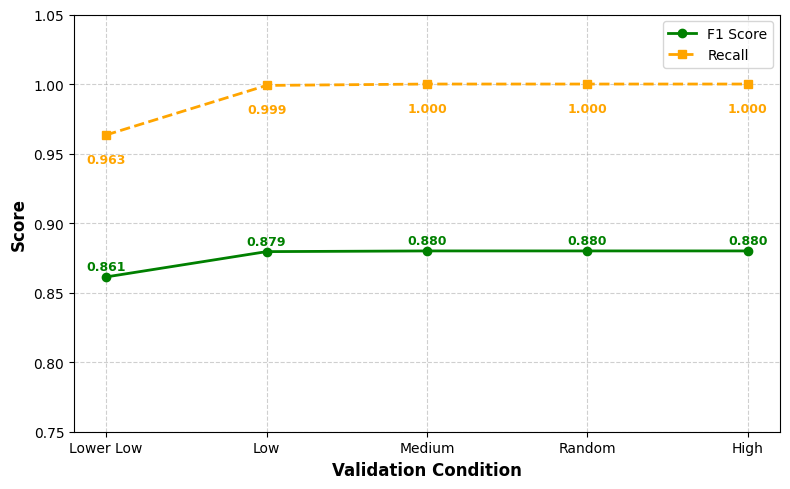

In [17]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.8613, 0.8795, 0.8800, 0.8800, 0.8800]
recalls =   [0.9634, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5))

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1+0.005, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec-0.02, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [34]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil


Processing validation files: 100%|██████████| 16/16 [00:07<00:00,  2.02it/s]


Total validation segments loaded: 7595


Formatting segments: 100%|██████████| 7595/7595 [00:00<00:00, 8663.78it/s]


Running inference on validation data...


Inference: 100%|██████████| 475/475 [00:40<00:00, 11.85it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9771
F1 Score:  0.9836
Precision: 0.9760
Recall:    0.9913

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2209             | 128              
Actual Positive: 46               | 5212             


{'accuracy': 0.9770901909150758,
 'f1': 0.9835818078882808,
 'precision': 0.9760299625468165,
 'recall': 0.9912514263978699}

In [18]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3385


Formatting segments: 100%|██████████| 3385/3385 [00:00<00:00, 8532.44it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.19it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9489
F1 Score:  0.9208
Precision: 0.8870
Recall:    0.9571

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2207             | 128              
Actual Positive: 45               | 1005             


{'accuracy': 0.9488921713441655,
 'f1': 0.9207512597343106,
 'precision': 0.8870255957634599,
 'recall': 0.9571428571428572}

In [19]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8582.64it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.11it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9619
F1 Score:  0.9422
Precision: 0.8914
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2207             | 128              
Actual Positive: 1                | 1051             


{'accuracy': 0.9619131975199291,
 'f1': 0.9421783953384133,
 'precision': 0.8914334181509754,
 'recall': 0.9990494296577946}

In [20]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8366.28it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.02it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9622
F1 Score:  0.9427
Precision: 0.8915
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2206             | 128              
Actual Positive: 0                | 1052             


{'accuracy': 0.9621972829297105,
 'f1': 0.942652329749104,
 'precision': 0.8915254237288136,
 'recall': 1.0}

In [21]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random


Processing validation files: 100%|██████████| 4/4 [00:04<00:00,  1.00s/it]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8263.46it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.01it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9622
F1 Score:  0.9427
Precision: 0.8915
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2206             | 128              
Actual Positive: 0                | 1052             


{'accuracy': 0.9621972829297105,
 'f1': 0.942652329749104,
 'precision': 0.8915254237288136,
 'recall': 1.0}

In [22]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8249.87it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 11.97it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9622
F1 Score:  0.9427
Precision: 0.8915
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2207             | 128              
Actual Positive: 0                | 1052             


{'accuracy': 0.9622084440507824,
 'f1': 0.942652329749104,
 'precision': 0.8915254237288136,
 'recall': 1.0}

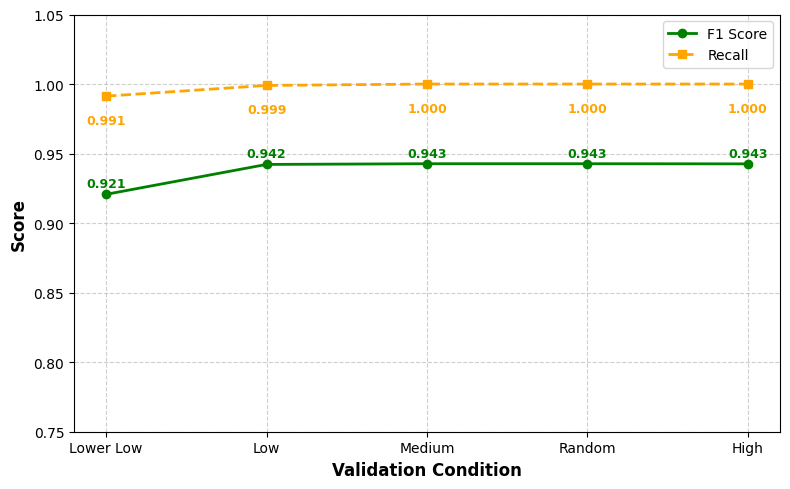

In [23]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9207, 0.9422, 0.9427, 0.9427,  0.9426]
recalls =   [0.9913, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5))

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1+0.005, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec-0.02, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [4]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen


Processing validation files:  56%|█████▋    | 9/16 [00:06<00:05,  1.30it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  69%|██████▉   | 11/16 [00:08<00:03,  1.48it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:14<00:00,  1.11it/s]


Total validation segments loaded: 7368


Formatting segments: 100%|██████████| 7368/7368 [00:00<00:00, 8094.35it/s]


Running inference on validation data...


Inference: 100%|██████████| 461/461 [00:38<00:00, 11.93it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9868
F1 Score:  0.9905
Precision: 0.9892
Recall:    0.9918

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2213             | 55               
Actual Positive: 42               | 5058             


{'accuracy': 0.9868349619978285,
 'f1': 0.9905023009889357,
 'precision': 0.9892431058087229,
 'recall': 0.991764705882353}

In [36]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Low


Processing validation files:  56%|█████▋    | 9/16 [00:05<00:06,  1.09it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  62%|██████▎   | 10/16 [00:06<00:04,  1.23it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:16<00:00,  1.05s/it]


Total validation segments loaded: 12929


Formatting segments: 100%|██████████| 12929/12929 [00:01<00:00, 8617.16it/s]


Running inference on validation data...


Inference: 100%|██████████| 809/809 [01:08<00:00, 11.84it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9501
F1 Score:  0.9221
Precision: 0.8944
Recall:    0.9517

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 8464             | 451              
Actual Positive: 194              | 3820             


{'accuracy': 0.9501121509784206,
 'f1': 0.9221484610742305,
 'precision': 0.8944041208147975,
 'recall': 0.9516691579471849}

In [6]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:48<00:00, 12.07s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 7025.04it/s]


Running inference on validation data...


Inference: 100%|██████████| 265/265 [00:22<00:00, 11.93it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9813
F1 Score:  0.9760
Precision: 0.9994
Recall:    0.9536

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 78               | 1604             


{'accuracy': 0.9813282911841172,
 'f1': 0.9759659263766353,
 'precision': 0.9993769470404984,
 'recall': 0.9536266349583828}

In [7]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:32<00:00,  8.01s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 7248.40it/s]


Running inference on validation data...


Inference: 100%|██████████| 232/232 [00:19<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9897
F1 Score:  0.9875
Precision: 1.0000
Recall:    0.9753

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 38               | 1503             


{'accuracy': 0.9897352782279849,
 'f1': 0.9875164257555847,
 'precision': 1.0,
 'recall': 0.9753406878650227}

In [11]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.89it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 8949.53it/s]


Running inference on validation data...


Inference: 100%|██████████| 174/174 [00:14<00:00, 12.10it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9733
F1 Score:  0.9167
Precision: 0.8462
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2289             | 74               
Actual Positive: 0                | 407              


{'accuracy': 0.9732851985559566,
 'f1': 0.9166666666666666,
 'precision': 0.8461538461538461,
 'recall': 1.0}

In [13]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files: 100%|██████████| 5/5 [00:04<00:00,  1.00it/s]


Total validation segments loaded: 4289


Formatting segments: 100%|██████████| 4289/4289 [00:00<00:00, 7637.92it/s]


Running inference on validation data...


Inference: 100%|██████████| 269/269 [00:22<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9564
F1 Score:  0.9530
Precision: 0.9102
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2206             | 187              
Actual Positive: 0                | 1896             


{'accuracy': 0.9564000932618326,
 'f1': 0.9530032671525509,
 'precision': 0.9102256361017763,
 'recall': 1.0}

In [14]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainKia/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:06<00:06,  3.16s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  75%|███████▌  | 3/4 [00:10<00:03,  3.49s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:12<00:00,  3.19s/it]


Total validation segments loaded: 7232


Formatting segments: 100%|██████████| 7232/7232 [00:00<00:00, 7371.30it/s]


Running inference on validation data...


Inference: 100%|██████████| 452/452 [00:38<00:00, 11.85it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9466
F1 Score:  0.9257
Precision: 0.8713
Recall:    0.9873

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 4443             | 355              
Actual Positive: 31               | 2403             


{'accuracy': 0.9466261061946902,
 'f1': 0.9256548536209553,
 'precision': 0.8712835387962291,
 'recall': 0.9872637633525062}

Train  on Gennesis

In [16]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia


Processing validation files: 100%|██████████| 16/16 [00:09<00:00,  1.77it/s]


Total validation segments loaded: 7425


Formatting segments: 100%|██████████| 7425/7425 [00:00<00:00, 8268.56it/s]


Running inference on validation data...


Inference: 100%|██████████| 465/465 [00:38<00:00, 11.99it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9820
F1 Score:  0.9870
Precision: 0.9847
Recall:    0.9893

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 55               | 5088             


{'accuracy': 0.9819528619528619,
 'f1': 0.9870029097963142,
 'precision': 0.9847106638281401,
 'recall': 0.9893058526152051}

In [15]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla


Processing validation files: 100%|██████████| 16/16 [00:07<00:00,  2.12it/s]


Total validation segments loaded: 7514


Formatting segments: 100%|██████████| 7514/7514 [00:00<00:00, 8365.18it/s]


Running inference on validation data...


Inference: 100%|██████████| 470/470 [00:38<00:00, 12.05it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9610
F1 Score:  0.9724
Precision: 0.9519
Recall:    0.9938

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2051             | 261              
Actual Positive: 32               | 5170             


{'accuracy': 0.9610061219057758,
 'f1': 0.9724442772500705,
 'precision': 0.9519425520162033,
 'recall': 0.9938485198000769}

In [ ]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil


Processing validation files: 100%|██████████| 16/16 [00:08<00:00,  1.85it/s]


Total validation segments loaded: 9142


Formatting segments: 100%|██████████| 9142/9142 [00:00<00:00, 10158.58it/s]


Running inference on validation data...


Inference: 100%|██████████| 572/572 [00:47<00:00, 12.00it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9790
F1 Score:  0.9849
Precision: 0.9795
Recall:    0.9904

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2681             | 131              
Actual Positive: 61               | 6269             


{'accuracy': 0.9789980310654124,
 'f1': 0.984917517674784,
 'precision': 0.97953125,
 'recall': 0.9903633491311217}

In [19]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Low


Processing validation files:  56%|█████▋    | 9/16 [00:06<00:07,  1.06s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  62%|██████▎   | 10/16 [00:07<00:05,  1.05it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:19<00:00,  1.24s/it]


Total validation segments loaded: 15574


Formatting segments: 100%|██████████| 15574/15574 [00:01<00:00, 10574.32it/s]


Running inference on validation data...


Inference: 100%|██████████| 974/974 [01:21<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9543
F1 Score:  0.9288
Precision: 0.9000
Recall:    0.9594

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 10226            | 515              
Actual Positive: 196              | 4637             


{'accuracy': 0.9543469885706948,
 'f1': 0.9287931897846771,
 'precision': 0.9000388198757764,
 'recall': 0.9594454789985516}

In [20]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.86it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 9082.00it/s]


Running inference on validation data...


Inference: 100%|██████████| 174/174 [00:14<00:00, 12.03it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9635
F1 Score:  0.8896
Precision: 0.8012
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2262             | 101              
Actual Positive: 0                | 407              


{'accuracy': 0.9635379061371842,
 'f1': 0.8896174863387978,
 'precision': 0.8011811023622047,
 'recall': 1.0}

In [21]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:06<00:06,  3.04s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  75%|███████▌  | 3/4 [00:09<00:03,  3.26s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:12<00:00,  3.04s/it]


Total validation segments loaded: 7232


Formatting segments: 100%|██████████| 7232/7232 [00:00<00:00, 7281.61it/s]


Running inference on validation data...


Inference: 100%|██████████| 452/452 [00:38<00:00, 11.83it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9527
F1 Score:  0.9336
Precision: 0.8854
Recall:    0.9873

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 4487             | 311              
Actual Positive: 31               | 2403             


{'accuracy': 0.9527101769911505,
 'f1': 0.9335664335664335,
 'precision': 0.8854089904200442,
 'recall': 0.9872637633525062}

In [25]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:38<00:00,  9.65s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 7047.05it/s]


Running inference on validation data...


Inference: 100%|██████████| 265/265 [00:45<00:00,  5.85it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9752
F1 Score:  0.9678
Precision: 0.9994
Recall:    0.9382

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 104              | 1578             


{'accuracy': 0.9751831718269912,
 'f1': 0.9678012879484821,
 'precision': 0.999366687777074,
 'recall': 0.9381688466111772}

In [23]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files: 100%|██████████| 5/5 [00:04<00:00,  1.01it/s]


Total validation segments loaded: 4289


Formatting segments: 100%|██████████| 4289/4289 [00:00<00:00, 7685.14it/s]


Running inference on validation data...


Inference: 100%|██████████| 269/269 [00:22<00:00, 11.90it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9573
F1 Score:  0.9540
Precision: 0.9120
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 183              
Actual Positive: 0                | 1896             


{'accuracy': 0.9573327115877827,
 'f1': 0.9539622641509434,
 'precision': 0.911976911976912,
 'recall': 1.0}

In [24]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:28<00:00,  7.18s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 7325.40it/s]


Running inference on validation data...


Inference: 100%|██████████| 232/232 [00:19<00:00, 11.96it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9900
F1 Score:  0.9878
Precision: 1.0000
Recall:    0.9760

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 37               | 1504             


{'accuracy': 0.9900054024851431,
 'f1': 0.9878489326765189,
 'precision': 1.0,
 'recall': 0.9759896171317326}

Train on Tesla

In [2]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia


Processing validation files: 100%|██████████| 16/16 [00:09<00:00,  1.75it/s]


Total validation segments loaded: 7425


Formatting segments: 100%|██████████| 7425/7425 [00:00<00:00, 8274.33it/s]


Running inference on validation data...


Inference: 100%|██████████| 465/465 [00:40<00:00, 11.57it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9820
F1 Score:  0.9870
Precision: 0.9847
Recall:    0.9893

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 55               | 5088             


{'accuracy': 0.9819528619528619,
 'f1': 0.9870029097963142,
 'precision': 0.9847106638281401,
 'recall': 0.9893058526152051}

In [3]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen


Processing validation files:  56%|█████▋    | 9/16 [00:06<00:05,  1.30it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  69%|██████▉   | 11/16 [00:08<00:03,  1.46it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:14<00:00,  1.10it/s]


Total validation segments loaded: 7368


Formatting segments: 100%|██████████| 7368/7368 [00:00<00:00, 8212.90it/s]


Running inference on validation data...


Inference: 100%|██████████| 461/461 [00:38<00:00, 11.97it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9959
F1 Score:  0.9971
Precision: 0.9994
Recall:    0.9947

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2265             | 3                
Actual Positive: 27               | 5073             


{'accuracy': 0.995928338762215,
 'f1': 0.9970518867924528,
 'precision': 0.9994089834515366,
 'recall': 0.9947058823529412}

In [5]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil


Processing validation files: 100%|██████████| 16/16 [00:10<00:00,  1.52it/s]


Total validation segments loaded: 7595


Formatting segments: 100%|██████████| 7595/7595 [00:00<00:00, 8757.56it/s]


Running inference on validation data...


Inference: 100%|██████████| 475/475 [00:39<00:00, 12.01it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9781
F1 Score:  0.9843
Precision: 0.9768
Recall:    0.9920

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2213             | 124              
Actual Positive: 42               | 5216             


{'accuracy': 0.9781435154707044,
 'f1': 0.9843366672957162,
 'precision': 0.9767790262172285,
 'recall': 0.9920121719284899}

In [6]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Low


Processing validation files:  56%|█████▋    | 9/16 [00:07<00:07,  1.07s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  62%|██████▎   | 10/16 [00:08<00:05,  1.05it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:22<00:00,  1.39s/it]


Total validation segments loaded: 15574


Formatting segments: 100%|██████████| 15574/15574 [00:01<00:00, 10562.39it/s]


Running inference on validation data...


Inference: 100%|██████████| 974/974 [01:21<00:00, 11.96it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9544
F1 Score:  0.9289
Precision: 0.9004
Recall:    0.9592

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 10228            | 513              
Actual Positive: 197              | 4636             


{'accuracy': 0.9544111981507641,
 'f1': 0.9288719695451814,
 'precision': 0.9003690036900369,
 'recall': 0.9592385681771156}

In [7]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.53it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 8843.62it/s]


Running inference on validation data...


Inference: 100%|██████████| 174/174 [00:14<00:00, 11.92it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9635
F1 Score:  0.8896
Precision: 0.8012
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2262             | 101              
Actual Positive: 0                | 407              


{'accuracy': 0.9635379061371842,
 'f1': 0.8896174863387978,
 'precision': 0.8011811023622047,
 'recall': 1.0}

In [8]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:06<00:06,  3.30s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  75%|███████▌  | 3/4 [00:10<00:03,  3.41s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:12<00:00,  3.23s/it]


Total validation segments loaded: 7232


Formatting segments: 100%|██████████| 7232/7232 [00:00<00:00, 7348.28it/s]


Running inference on validation data...


Inference: 100%|██████████| 452/452 [00:38<00:00, 11.83it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9527
F1 Score:  0.9336
Precision: 0.8854
Recall:    0.9873

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 4487             | 311              
Actual Positive: 31               | 2403             


{'accuracy': 0.9527101769911505,
 'f1': 0.9335664335664335,
 'precision': 0.8854089904200442,
 'recall': 0.9872637633525062}

In [9]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:36<00:00,  9.18s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 7259.71it/s]


Running inference on validation data...


Inference: 100%|██████████| 265/265 [00:22<00:00, 11.92it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9747
F1 Score:  0.9672
Precision: 0.9994
Recall:    0.9370

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 106              | 1576             


{'accuracy': 0.9747104703379815,
 'f1': 0.9671678428965941,
 'precision': 0.9993658845909955,
 'recall': 0.9369797859690844}

In [10]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files: 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]


Total validation segments loaded: 4289


Formatting segments: 100%|██████████| 4289/4289 [00:00<00:00, 7682.29it/s]


Running inference on validation data...


Inference: 100%|██████████| 269/269 [00:22<00:00, 11.91it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9573
F1 Score:  0.9540
Precision: 0.9120
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 183              
Actual Positive: 0                | 1896             


{'accuracy': 0.9573327115877827,
 'f1': 0.9539622641509434,
 'precision': 0.911976911976912,
 'recall': 1.0}

In [11]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:28<00:00,  7.11s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 7348.20it/s]


Running inference on validation data...


Inference: 100%|██████████| 232/232 [00:19<00:00, 11.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9897
F1 Score:  0.9875
Precision: 1.0000
Recall:    0.9753

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 38               | 1503             


{'accuracy': 0.9897352782279849,
 'f1': 0.9875164257555847,
 'precision': 1.0,
 'recall': 0.9753406878650227}

Tran on Silverado

In [12]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia


Processing validation files: 100%|██████████| 16/16 [00:07<00:00,  2.00it/s]


Total validation segments loaded: 7425


Formatting segments: 100%|██████████| 7425/7425 [00:00<00:00, 8239.48it/s]


Running inference on validation data...


Inference: 100%|██████████| 465/465 [00:38<00:00, 12.10it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9141
F1 Score:  0.9410
Precision: 0.8968
Recall:    0.9899

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 1696             | 586              
Actual Positive: 52               | 5091             


{'accuracy': 0.914074074074074,
 'f1': 0.9410351201478743,
 'precision': 0.8967764664435441,
 'recall': 0.9898891697452848}

In [13]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla


Processing validation files: 100%|██████████| 16/16 [00:08<00:00,  1.90it/s]


Total validation segments loaded: 7514


Formatting segments: 100%|██████████| 7514/7514 [00:00<00:00, 8261.33it/s]


Running inference on validation data...


Inference: 100%|██████████| 470/470 [00:39<00:00, 11.98it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9034
F1 Score:  0.9345
Precision: 0.8804
Recall:    0.9958

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 1608             | 704              
Actual Positive: 22               | 5180             


{'accuracy': 0.9033803566675539,
 'f1': 0.9345119971134764,
 'precision': 0.8803535010197144,
 'recall': 0.9957708573625529}

In [14]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen


Processing validation files:  56%|█████▋    | 9/16 [00:05<00:04,  1.54it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  69%|██████▉   | 11/16 [00:06<00:02,  1.72it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:12<00:00,  1.25it/s]


Total validation segments loaded: 7368


Formatting segments: 100%|██████████| 7368/7368 [00:00<00:00, 8242.80it/s]


Running inference on validation data...


Inference: 100%|██████████| 461/461 [00:38<00:00, 11.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9473
F1 Score:  0.9632
Precision: 0.9326
Recall:    0.9959

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 1901             | 367              
Actual Positive: 21               | 5079             


{'accuracy': 0.9473398479913138,
 'f1': 0.9632087995448512,
 'precision': 0.9326110907087771,
 'recall': 0.9958823529411764}

In [15]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Low


Processing validation files:  56%|█████▋    | 9/16 [00:05<00:06,  1.15it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  62%|██████▎   | 10/16 [00:06<00:04,  1.29it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 16/16 [00:15<00:00,  1.00it/s]


Total validation segments loaded: 12929


Formatting segments: 100%|██████████| 12929/12929 [00:01<00:00, 8779.07it/s]


Running inference on validation data...


Inference: 100%|██████████| 809/809 [01:08<00:00, 11.89it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.8749
F1 Score:  0.8281
Precision: 0.7220
Recall:    0.9706

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 7415             | 1500             
Actual Positive: 118              | 3896             


{'accuracy': 0.8748549771830768,
 'f1': 0.8280552603613177,
 'precision': 0.7220163083765753,
 'recall': 0.9706028898854011}

In [16]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:04<00:00,  1.25it/s]


Total validation segments loaded: 4430


Formatting segments: 100%|██████████| 4430/4430 [00:00<00:00, 14150.75it/s]


Running inference on validation data...


Inference: 100%|██████████| 277/277 [00:23<00:00, 12.03it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9621
F1 Score:  0.8840
Precision: 0.7921
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 3622             | 168              
Actual Positive: 0                | 640              


{'accuracy': 0.9620767494356659,
 'f1': 0.8839779005524862,
 'precision': 0.7920792079207921,
 'recall': 1.0}

In [17]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:06<00:06,  3.08s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  75%|███████▌  | 3/4 [00:09<00:03,  3.23s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:12<00:00,  3.04s/it]


Total validation segments loaded: 7594


Formatting segments: 100%|██████████| 7594/7594 [00:00<00:00, 7683.13it/s]


Running inference on validation data...


Inference: 100%|██████████| 475/475 [00:40<00:00, 11.87it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9048
F1 Score:  0.8750
Precision: 0.7830
Recall:    0.9914

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 4341             | 701              
Actual Positive: 22               | 2530             


{'accuracy': 0.904793257835133,
 'f1': 0.8749783849213211,
 'precision': 0.7830393067161869,
 'recall': 0.9913793103448276}

In [18]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:46<00:00, 11.71s/it]


Total validation segments loaded: 5283


Formatting segments: 100%|██████████| 5283/5283 [00:00<00:00, 9032.20it/s] 


Running inference on validation data...


Inference: 100%|██████████| 331/331 [00:27<00:00, 12.04it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9735
F1 Score:  0.9659
Precision: 0.9866
Recall:    0.9461

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 3161             | 27               
Actual Positive: 113              | 1982             


{'accuracy': 0.9734999053568049,
 'f1': 0.9658869395711501,
 'precision': 0.9865604778496765,
 'recall': 0.9460620525059665}

In [19]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:36<00:00,  9.15s/it]


Total validation segments loaded: 4816


Formatting segments: 100%|██████████| 4816/4816 [00:00<00:00, 9500.63it/s] 


Running inference on validation data...


Inference: 100%|██████████| 301/301 [00:24<00:00, 12.05it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9259
F1 Score:  0.9167
Precision: 0.8618
Recall:    0.9791

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2495             | 315              
Actual Positive: 42               | 1964             


{'accuracy': 0.9258720930232558,
 'f1': 0.9166861143523921,
 'precision': 0.8617814831066257,
 'recall': 0.9790628115653041}